In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [8]:
def read_csv_helper(fpath):
    splits = fpath.split("=")
    cutoff = splits[1].split(".")[0]
    #fips = splits[1].split("_")[0]
    df = pd.read_csv(fpath, header=None)
    
    old_cols = list(df.columns)
    
    #df["fips"] = int(fips)
    df["cutoff"] = int(cutoff)
    
    df = df[["cutoff"] + old_cols]
    
    return df

In [10]:
combined_df_path = "./depths_by_cutoff.csv"
if os.path.exists(combined_df_path):
    print("{} exists! Loading!".format(combined_df_path))
    combined_df = pd.read_csv(combined_df_path)
else:
    print("{} does not exist! Creating!".format(combined_df_path))
    depths_subfolder = "./depths"
    file_paths = [os.path.join(depths_subfolder, filename) for filename in os.listdir(depths_subfolder)]
    with concurrent.futures.ProcessPoolExecutor(max_workers=cpu_count()) as executor:
        # Submit file reading tasks to the executor
        futures = [executor.submit(read_csv_helper, file_path) for file_path in file_paths]

        # Use tqdm to display progress
        progress_bar = tqdm(total=len(futures))
        dfs = []

        # Retrieve the results as they complete
        for future in concurrent.futures.as_completed(futures):
            df = future.result()
            dfs.append(df)
            progress_bar.update(1)

    # Close the progress bar
    progress_bar.close()

    # Concatenate the DataFrames into a single DataFrame
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df = combined_df.sort_values(by=["cutoff"])
    print("Writing {}".format(combined_df_path))
    combined_df.to_csv(combined_df_path, index=False)

./depths_by_cutoff.csv does not exist! Creating!



Writing ./depths_by_cutoff.csv


### Depths by Date

In [12]:
columns_to_exclude = ["fips"]
mean_depths_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : np.mean(x.loc[:, ~x.columns.isin(columns_to_exclude)].values))
median_depths_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : np.median(x.loc[:, ~x.columns.isin(columns_to_exclude)].values))
max_depths_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : np.max(x.loc[:, ~x.columns.isin(columns_to_exclude)].values))
min_depths_by_cutoff = combined_df.groupby("cutoff").apply(lambda x : np.min(x.loc[:, ~x.columns.isin(columns_to_exclude)].values))


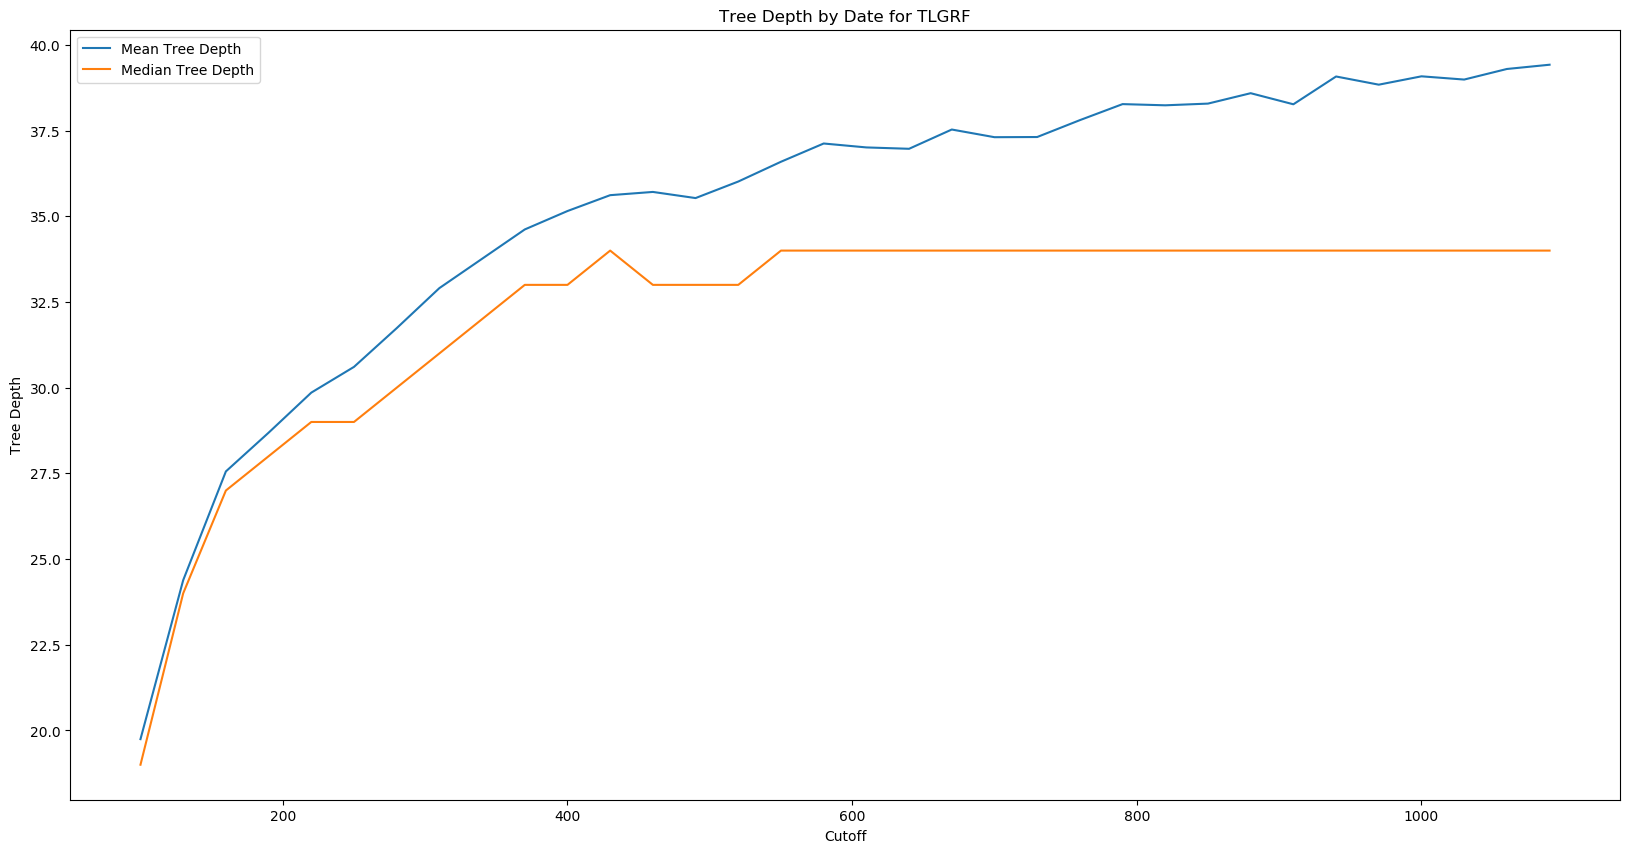

In [16]:
plt.figure(figsize=(20,10))
#plt.plot(max_depths_by_cutoff,label="Max Tree Depth")
plt.plot(mean_depths_by_cutoff,label="Mean Tree Depth")
plt.plot(median_depths_by_cutoff,label="Median Tree Depth")
#plt.plot(min_depths_by_cutoff,label="Min Tree Depth")

plt.ylabel("Tree Depth")
plt.xlabel("Cutoff")
plt.title("Tree Depth by Date for TLGRF")
#plt.ylim(0,4.5)
plt.legend()
plt.show()

In [14]:
mean_depths_by_cutoff

cutoff
100     19.746269
130     24.383085
160     27.557214
190     28.686567
220     29.855721
250     30.606965
280     31.736318
310     32.905473
370     34.616915
400     35.154229
430     35.616915
460     35.711443
490     35.532338
520     36.014925
550     36.592040
580     37.124378
610     37.009950
640     36.970149
670     37.532338
700     37.308458
730     37.313433
760     37.805970
790     38.273632
820     38.238806
850     38.288557
880     38.592040
910     38.268657
940     39.079602
970     38.840796
1000    39.084577
1030    38.990050
1060    39.298507
1090    39.422886
dtype: float64